# Fixed-effects benchmark: one PDU and five MI

Generate a synthetic longitudinal data set, calibrate it with the current SAEM implementation, and compare observations with individual fitted predictions.

The analytical model has one patient-specific amplitude $A_i$ (the **PDU**) and five shared shape coefficients $m_1,\ldots,m_5$ (the **MI**):

$$
\begin{aligned}
\log A_i &= \mu_A + \eta_i, & \eta_i &\sim \mathcal N(0,\omega_A^2),\\
f_i(t) &= A_i\left[1+m_1\cos u+m_2\sin u+m_3\cos(2u)
                       +m_4\sin(2u)+m_5\cos(3u)\right],
& u &= 2\pi t/24,\\
y_i(t) &= f_i(t)+\varepsilon_{it}, & \varepsilon_{it} &\sim\mathcal N(0,\sigma^2).
\end{aligned}
$$

Each patient is observed at times 0 through 23. Over this complete period, the five harmonic terms have zero mean and are mutually orthogonal. The fixed baseline of 1 anchors the amplitude, so its population mean is not confounded with an MI intercept. All five MI and the amplitude distribution and residual variance are estimated.

The simulated amplitudes and noiseless signals are retained only for evaluation; SAEM receives the noisy observations. This is a small calibration benchmark, not a validation of the fixed-effects chain-averaging approximation.

In [1]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from vpop_calibration.api import (
    Config,
    NlmeConfigDict,
    NlmeModel,
    SaemConfigDict,
    StructuralAnalytical,
)

# These small tensor batches run efficiently with one CPU thread.
torch.set_num_threads(1)
plt.rcParams.update(
    {"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False}
)

## Analytical model and synthetic observations

The same analytical function is used to generate and fit the data. All five MI are positive and use the library's default log transformation.

In [2]:
PERIOD = 24.0
MI_NAMES = [f"mi_{j}" for j in range(1, 6)]


def periodic_signal(amplitude, mi_1, mi_2, mi_3, mi_4, mi_5, t):
    u = 2.0 * torch.pi * t / PERIOD
    return amplitude * (
        1.0
        + mi_1 * torch.cos(u)
        + mi_2 * torch.sin(u)
        + mi_3 * torch.cos(2.0 * u)
        + mi_4 * torch.sin(2.0 * u)
        + mi_5 * torch.cos(3.0 * u)
    )


struct_model = StructuralAnalytical(periodic_signal, ["signal"])

NB_PATIENTS = 60
TIMES = np.arange(24, dtype=float)  # Exclude the duplicated endpoint at t = 24.
TRUE_AMPLITUDE_MEDIAN = 2.0
TRUE_LOG_AMPLITUDE_SD = 0.35
TRUE_MI = dict(zip(MI_NAMES, [0.25, 0.18, 0.15, 0.12, 0.08]))
TRUE_NOISE_SD = 0.10
SIMULATION_SEED = 2026
CALIBRATION_SEED = 2027

rng = np.random.default_rng(SIMULATION_SEED)
patient_ids = [f"patient_{i:03d}" for i in range(NB_PATIENTS)]
true_amplitudes = rng.lognormal(
    mean=np.log(TRUE_AMPLITUDE_MEDIAN), sigma=TRUE_LOG_AMPLITUDE_SD, size=NB_PATIENTS
)
true_signals = (
    periodic_signal(
        amplitude=torch.as_tensor(true_amplitudes[:, None]),
        t=torch.as_tensor(TIMES[None, :]),
        **TRUE_MI,
    )
    .detach()
    .cpu()
    .numpy()
)
observed_values = true_signals + rng.normal(0.0, TRUE_NOISE_SD, true_signals.shape)

truth_df = pd.DataFrame(
    {
        "id": np.repeat(patient_ids, len(TIMES)),
        "time": np.tile(TIMES, NB_PATIENTS),
        "protocol_arm": "identity",
        "output_name": "signal",
        "value": observed_values.ravel(),
        "true_signal": true_signals.ravel(),
        "true_amplitude": np.repeat(true_amplitudes, len(TIMES)),
    }
)
observation_columns = ["id", "time", "protocol_arm", "output_name", "value"]
obs_df = truth_df[observation_columns].copy()
print(f"{NB_PATIENTS} patients × {len(TIMES)} times = {len(obs_df)} observations")
display(obs_df.head())

60 patients × 24 times = 1440 observations


,id,time,protocol_arm,output_name,value
0,patient_000,0.0,identity,signal,2.143971
1,patient_000,1.0,identity,signal,2.224857
2,patient_000,2.0,identity,signal,2.153910
3,patient_000,3.0,identity,signal,1.928921
4,patient_000,4.0,identity,signal,1.772124


## SAEM calibration

Starting values differ from the generating values. `prior_omega` and `initial_variance` are **variances**, not standard deviations. `nb_chains` controls the calibration MCMC branches. Live plots are disabled so the complete fit can also run non-interactively.

  0%|          | 0/350 [00:00<?, ?it/s]

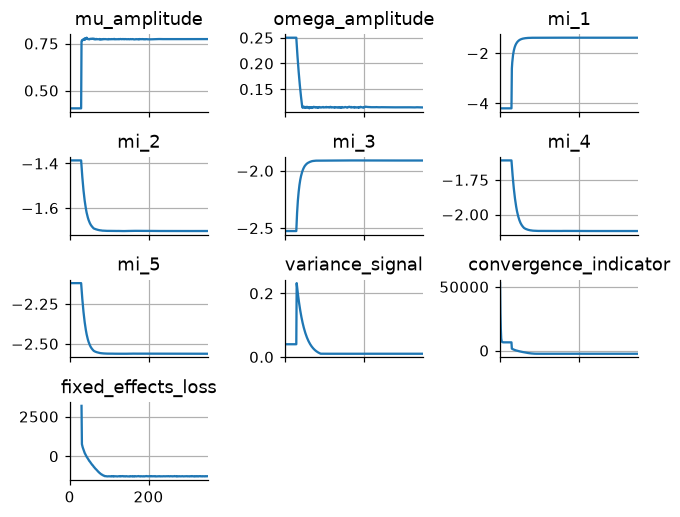

SAEM: 350 iterations in 12.01 seconds


In [14]:
model_params = {
    "pdu": {"amplitude": {"prior": 1.5, "prior_omega": 0.5**2}},
    "model_intrinsic": {
        "mi_1": {"prior": 0.015, "step_scale": 1},
        "mi_2": {"prior": 0.25, "step_scale": 1},
        "mi_3": {"prior": 0.08, "step_scale": 1},
        "mi_4": {"prior": 0.20, "step_scale": 1},
        "mi_5": {"prior": 0.12, "step_scale": 1},
    },
    "error_model": {"signal": {"error_type": "additive", "initial_variance": 0.2**2}},
}

config = Config(
    seed=CALIBRATION_SEED,
    nlme=NlmeConfigDict(nb_chains=5, live_plot=False, progress_bar=False),
    saem=SaemConfigDict(
        nb_iter_burnin=30,
        nb_iter_learning=170,
        nb_iter_smoothing=150,
        nb_mcmc_transitions=3,
        annealing_factor=0.95,
        fixed_effects_lr=1e-1,
        fixed_effects_grad_scale=1e-3,
        learning_rate_power=0.5,
        live_plot=True,
        progress_bars=True,
        logging=False,
        fixed_effects_patient_batch_size=None,
        fixed_effects_preconditioner="fisher",
    ),
)

nlme_model = NlmeModel(
    structural_model=struct_model,
    df=obs_df,
    input_params=model_params,
    config=config,
)
model = nlme_model.statistical_model
assert model.nb_pdu == 1 and model.nb_mi == 5

started = perf_counter()
nlme_model.optimizer.run()
calibration_seconds = perf_counter() - started
history = nlme_model.optimizer.history.copy()
print(f"SAEM: {len(history)} iterations in {calibration_seconds:.2f} seconds")

In [12]:
# Convert the estimated parameters back to the physical scale.
mi_full_tensor = torch.unsqueeze(torch.unsqueeze(model.log_mi, 0), 0)
mi_physical_values = model.mi_transform(mi_full_tensor).detach().cpu().numpy()
estimated_mi = dict(zip(model.mi_names, mi_physical_values[0, 0, :]))
parameter_rows = [
    {
        "parameter": "Amplitude median",
        "truth": TRUE_AMPLITUDE_MEDIAN,
        "initial": model_params["pdu"]["amplitude"]["prior"],
        "estimated": model.population_betas[0].exp().item(),
    },
    {
        "parameter": "SD(log amplitude)",
        "truth": TRUE_LOG_AMPLITUDE_SD,
        "initial": np.sqrt(model_params["pdu"]["amplitude"]["prior_omega"]),
        "estimated": model.omega_pop[0, 0].sqrt().item(),
    },
    *[
        {
            "parameter": name,
            "truth": TRUE_MI[name],
            "initial": model_params["model_intrinsic"][name]["prior"],
            "estimated": estimated_mi[name],
        }
        for name in MI_NAMES
    ],
    {
        "parameter": "Residual SD",
        "truth": TRUE_NOISE_SD,
        "initial": np.sqrt(model_params["error_model"]["signal"]["initial_variance"]),
        "estimated": model.residual_var.additive_variance[0].sqrt().item(),
    },
]
parameter_comparison = pd.DataFrame(parameter_rows).set_index("parameter")
parameter_comparison["relative_error_pct"] = 100.0 * (
    parameter_comparison["estimated"] / parameter_comparison["truth"] - 1.0
)
display(parameter_comparison.round(4))

,truth,initial,estimated,relative_error_pct
parameter,,,,
Amplitude median,2.00,1.500,2.1674,8.3683
SD(log amplitude),0.35,0.500,0.3387,-3.2410
mi_1,0.25,0.015,0.2500,-0.0075
mi_2,0.18,0.250,0.1824,1.3441
mi_3,0.15,0.080,0.1480,-1.3596
mi_4,0.12,0.200,0.1206,0.4654
mi_5,0.08,0.120,0.0772,-3.4497
Residual SD,0.10,0.200,0.1005,0.5445


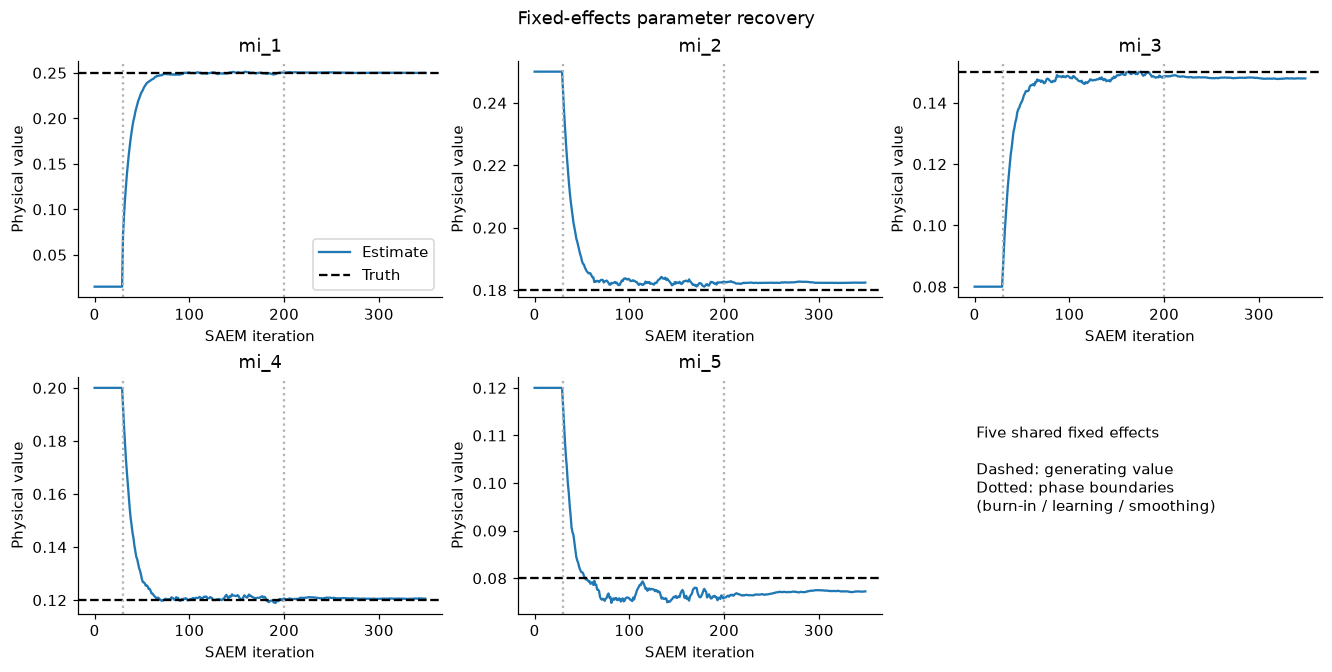

In [13]:
# The optimizer records positive MI on the log scale.
fig, axes = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)
for ax, name in zip(axes.flat, MI_NAMES):
    ax.plot(history["iteration"], np.exp(history[name]), color="C0", label="Estimate")
    ax.axhline(TRUE_MI[name], color="black", linestyle="--", label="Truth")
    ax.set(title=name, xlabel="SAEM iteration", ylabel="Physical value")
    ax.axvline(config.saem.nb_iter_burnin, color="0.7", linestyle=":")
    ax.axvline(
        config.saem.nb_iter_burnin + config.saem.nb_iter_learning,
        color="0.7",
        linestyle=":",
    )
axes.flat[0].legend()
axes.flat[-1].axis("off")
axes.flat[-1].text(
    0.05,
    0.8,
    "Five shared fixed effects\n\nDashed: generating value\n"
    "Dotted: phase boundaries\n(burn-in / learning / smoothing)",
    va="top",
    transform=axes.flat[-1].transAxes,
)
fig.suptitle("Fixed-effects parameter recovery")
plt.show()
plt.close(fig)

## Observations versus fitted predictions

At the fitted population parameters, sample each patient's conditional distribution and use the best sampled individual posterior state (an approximate MAP estimate) to predict the observations. These are **in-sample fitted predictions**, with no additional residual noise. The comparison with the hidden noiseless signal is available because this data set is synthetic.

In [54]:
nlme_model.diagnostics.sample_conditional_distribution(nb_samples=300)
predictions_df = nlme_model.diagnostics.sampler.map_predictions_df.copy()
keys = ["id", "time", "protocol_arm", "output_name"]
comparison_df = truth_df.merge(
    predictions_df[keys + ["predicted_value"]],
    on=keys,
    how="left",
    validate="one_to_one",
).rename(columns={"predicted_value": "fitted_signal"})
assert comparison_df["fitted_signal"].notna().all()

metrics = []
for reference, label in [
    ("value", "Observed data"),
    ("true_signal", "Noiseless truth"),
]:
    error = comparison_df["fitted_signal"] - comparison_df[reference]
    metrics.append(
        {
            "reference": label,
            "RMSE": np.sqrt(np.mean(error**2)),
            "MAE": np.mean(np.abs(error)),
            "mean_error": np.mean(error),
        }
    )
fit_metrics = pd.DataFrame(metrics).set_index("reference")
display(fit_metrics.round(4))
print(f"Generating residual SD: {TRUE_NOISE_SD:.3f}")

,RMSE,MAE,mean_error
reference,,,
Observed data,0.0984,0.0783,0.0004
Noiseless truth,0.0233,0.0183,-0.0026


Generating residual SD: 0.100


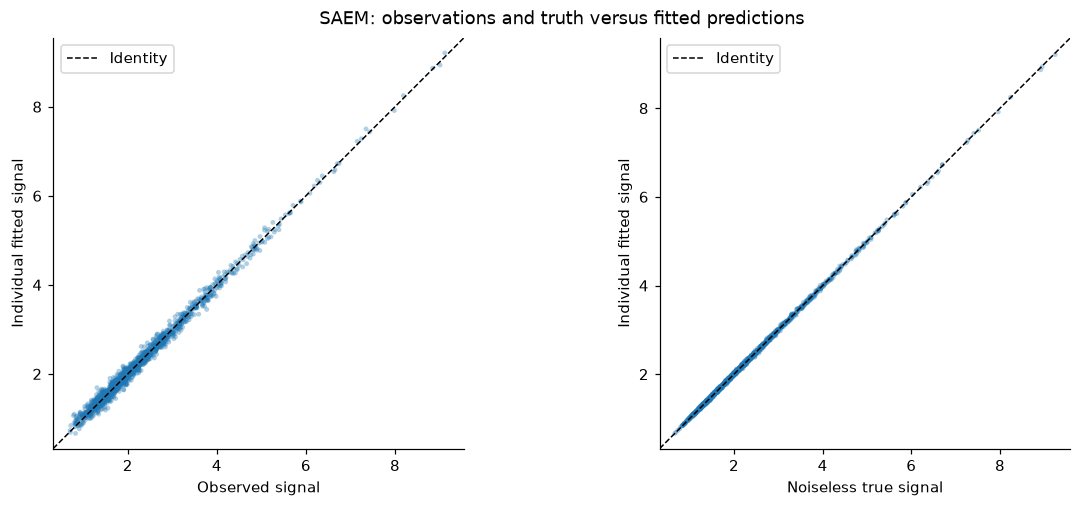

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for ax, reference, label in zip(
    axes, ["value", "true_signal"], ["Observed signal", "Noiseless true signal"]
):
    ax.scatter(
        comparison_df[reference],
        comparison_df["fitted_signal"],
        s=10,
        alpha=0.35,
        color="C0",
        edgecolors="none",
    )
    lower = min(comparison_df[reference].min(), comparison_df["fitted_signal"].min())
    upper = max(comparison_df[reference].max(), comparison_df["fitted_signal"].max())
    padding = 0.04 * (upper - lower)
    limits = (lower - padding, upper + padding)
    ax.plot(limits, limits, "k--", linewidth=1, label="Identity")
    ax.set(xlabel=label, ylabel="Individual fitted signal", xlim=limits, ylim=limits)
    ax.set_aspect("equal", adjustable="box")
    ax.legend()
fig.suptitle("SAEM: observations and truth versus fitted predictions")
plt.show()
plt.close(fig)

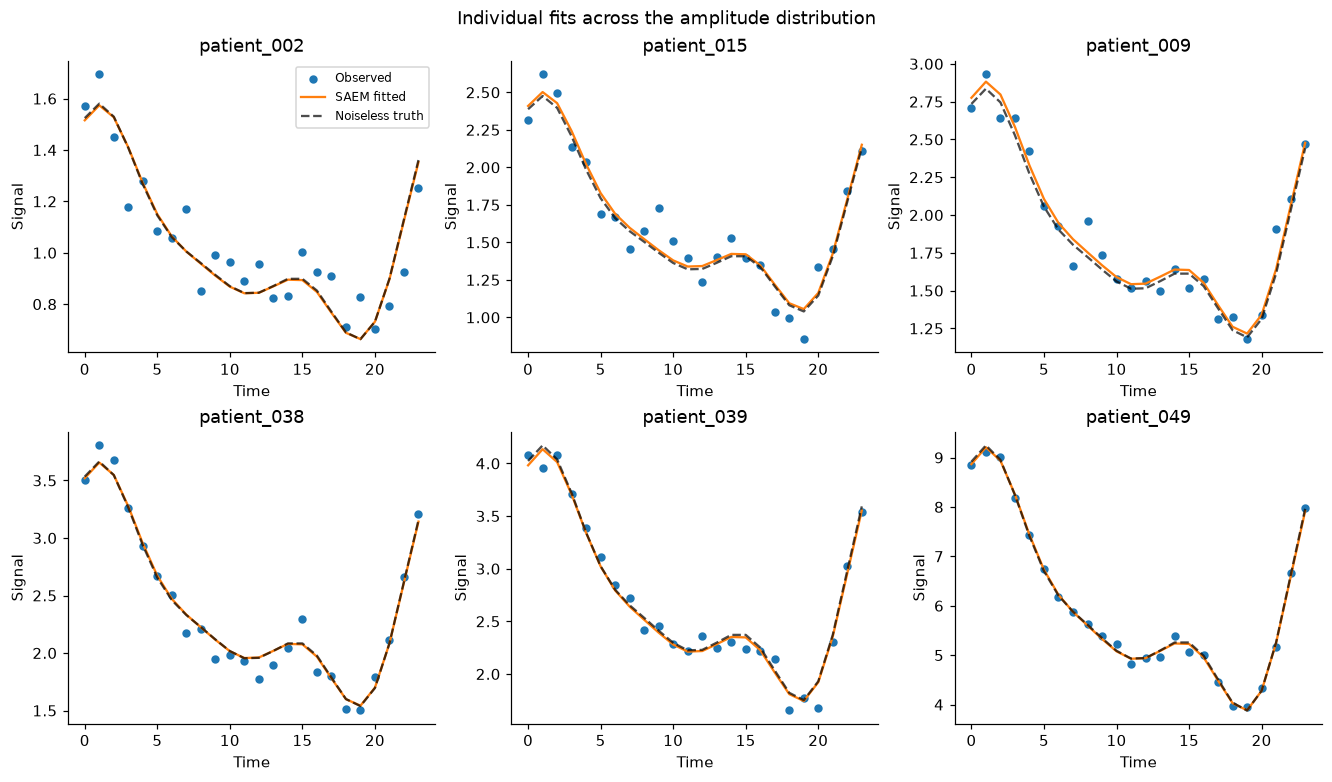

In [56]:
# Show patients spanning the simulated amplitude distribution.
ordered_ids = (
    truth_df[["id", "true_amplitude"]]
    .drop_duplicates()
    .sort_values("true_amplitude")["id"]
    .to_numpy()
)
selected_ids = ordered_ids[np.linspace(0, NB_PATIENTS - 1, 6, dtype=int)]
fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
for ax, patient_id in zip(axes.flat, selected_ids):
    patient = comparison_df.loc[comparison_df["id"] == patient_id].sort_values("time")
    ax.scatter(patient["time"], patient["value"], s=20, color="C0", label="Observed")
    ax.plot(patient["time"], patient["fitted_signal"], color="C1", label="SAEM fitted")
    ax.plot(
        patient["time"],
        patient["true_signal"],
        "k--",
        alpha=0.7,
        label="Noiseless truth",
    )
    ax.set(title=patient_id, xlabel="Time", ylabel="Signal")
axes.flat[0].legend(fontsize=8)
fig.suptitle("Individual fits across the amplitude distribution")
plt.show()
plt.close(fig)